training a model that can predict what type of clothing item is in a photo, using the Fashion MNIST database


In [12]:
import tensorflow as tf
from tensorflow import keras

print("Se descarca Fashion MNIST")
MNIST = keras.datasets.fashion_mnist

(train_images, train_labels) , (test_images, test_labels) = MNIST.load_data()

#train_images = train_images.reshape(-1, 28, 28, 1)
#test_images = test_images.reshape(-1, 28, 28, 1)

train_images = (train_images.astype("float32") / 255.0).reshape(-1, 28, 28, 1)
test_images  = (test_images.astype("float32") / 255.0).reshape(-1, 28, 28, 1)

print(f" Avem {len(train_images)} imagini de antrenament")
print(f"Dimensiunea este de {train_images[0].shape} pixeli")


Se descarca Fashion MNIST
 Avem 60000 imagini de antrenament
Dimensiunea este de (28, 28, 1) pixeli


initialize the CNN model, convolution -> pooling -> second convolution layer -> flattening -> full connected layer -> output layer

In [13]:

cnn = tf.keras.models.Sequential()

#added after
cnn.add(tf.keras.layers.Input(shape=(28, 28, 1)))

#changed filters from 20 to 32 and kernel size from 8 to 3
#this is the convolution block 1
cnn.add(tf.keras.layers.Conv2D(filters = 32, kernel_size = 3, activation = 'relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size = 2, strides = 2))

#this is convolution block 2
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))


cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dropout(0.3))
cnn.add(tf.keras.layers.Dense(units=10, activation='softmax'))

TRAINING THE CNN 

compiling the cnn -> training the cnn on the training set and evaluating it on the test set 

In [14]:
cnn.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

cnn.fit(x = train_images, y = train_labels, validation_data = (test_images, test_labels), epochs = 25)

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.7531 - loss: 0.6958 - val_accuracy: 0.8618 - val_loss: 0.3901
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.8645 - loss: 0.3779 - val_accuracy: 0.8806 - val_loss: 0.3363
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.8837 - loss: 0.3250 - val_accuracy: 0.8875 - val_loss: 0.3106
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.8961 - loss: 0.2899 - val_accuracy: 0.8951 - val_loss: 0.2870
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.8988 - loss: 0.2789 - val_accuracy: 0.8998 - val_loss: 0.2775
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9032 - loss: 0.2638 - val_accuracy: 0.8988 - val_loss: 0.2770
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9077 - loss: 0.2520 - val_accuracy: 0.9034 - val_loss: 0.2643
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9119 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9100 - loss: 0.2570
Test Accuracy: 91.02%
Test Loss: 0.2495
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Image 0: Predicted=Ankle boot (100.0%), True=Ankle boot


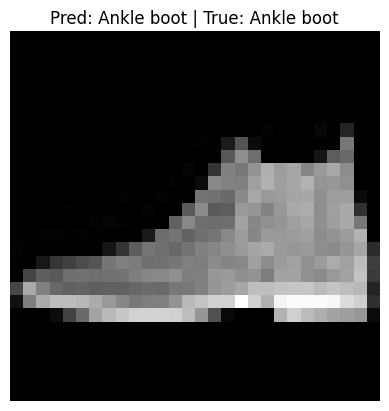

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Image 1: Predicted=Pullover (99.9%), True=Pullover


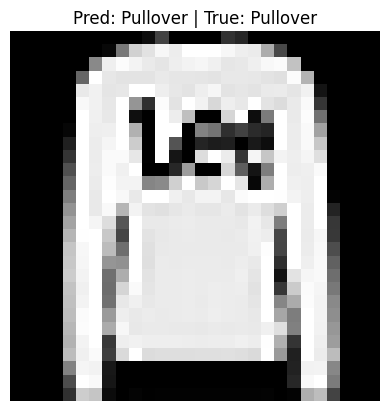

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Image 2: Predicted=Trouser (100.0%), True=Trouser


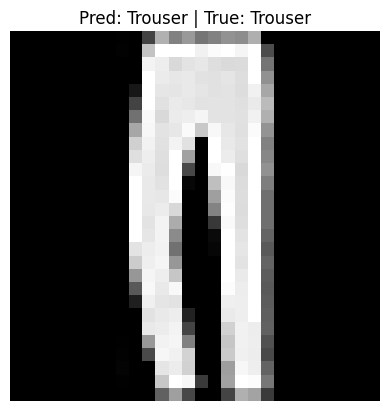

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Image 3: Predicted=Trouser (100.0%), True=Trouser


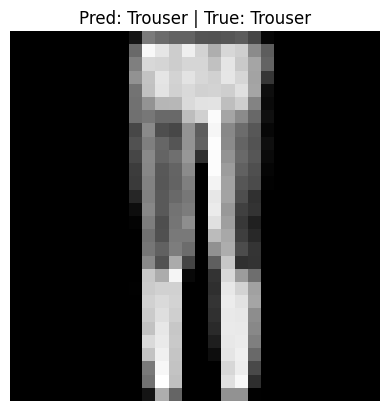

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Image 4: Predicted=Shirt (83.1%), True=Shirt


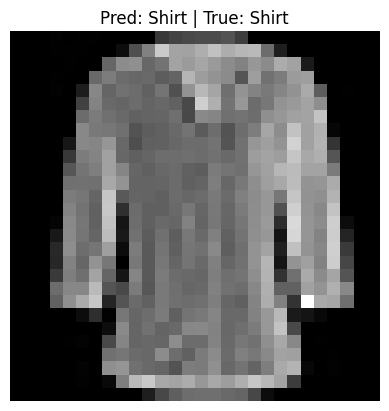

In [15]:
# 1. Evaluate on test set (overall accuracy)
test_loss, test_accuracy = cnn.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 2. See predictions on multiple test images
import matplotlib.pyplot as plt

num_images = 5
for i in range(num_images):
    # Get a test image
    test_img = test_images[i:i+1]  # shape (1, 28, 28, 1)
    
    # Predict
    prediction = cnn.predict(test_img)
    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class]
    
    # Get true label
    true_class = test_labels[i]
    
    # Display
    print(f"Image {i}: Predicted={class_names[predicted_class]} ({confidence*100:.1f}%), True={class_names[true_class]}")
    
    # Show the image
    plt.imshow(test_images[i], cmap='gray')
    plt.title(f"Pred: {class_names[predicted_class]} | True: {class_names[true_class]}")
    plt.axis('off')
    plt.show()

making a single prediction based on a image taken from online

In [7]:
!ls /content

black_white_tshirt.jpg	dress.jpg     sneaker3.jpg  sneaker6.jpg
dress_blackBG2.jpg	sample_data   sneaker4.jpg  sneaker.jpg
dress_blackBG.jpg	sneaker2.jpg  sneaker5.jpg


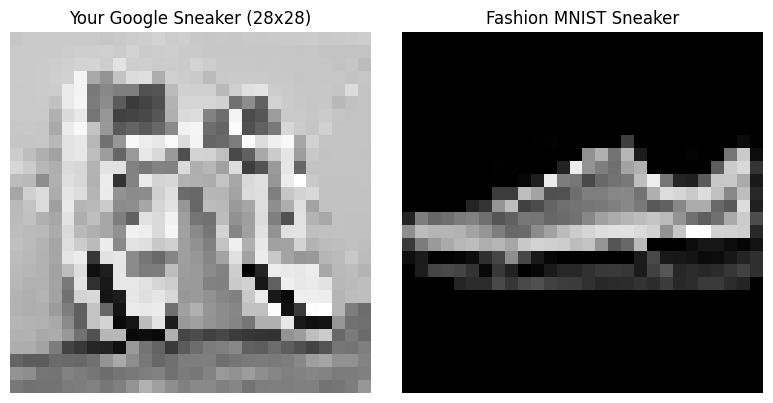

Your image pixel range: 0.00 to 0.99
Fashion MNIST pixel range: 0.0 to 1.0


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Load your Google image
test_image = image.load_img('sneaker.jpg', 
                             target_size=(28, 28), 
                             color_mode='grayscale')

# Show it side-by-side with a Fashion MNIST sneaker
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Your Google image (processed)
test_array = image.img_to_array(test_image) / 255.0
axes[0].imshow(test_array.reshape(28, 28), cmap='gray')
axes[0].set_title("Your Google Sneaker (28x28)")
axes[0].axis('off')

# Fashion MNIST sneaker example (class 7 = Sneaker)
sneaker_idx = np.where(test_labels == 7)[0][0]
axes[1].imshow(test_images[sneaker_idx].reshape(28, 28), cmap='gray')
axes[1].set_title("Fashion MNIST Sneaker")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Your image pixel range: {test_array.min():.2f} to {test_array.max():.2f}")
print(f"Fashion MNIST pixel range: {test_images.min()} to {test_images.max()}")

In [25]:
import numpy as np
from tensorflow.keras.preprocessing import image


# Class names for Fashion MNIST (index 0 to 9)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 1. Load image as grayscale and resize to 28x28
test_image = image.load_img('black_white_tshirt.jpg', 
                             target_size=(28, 28), 
                             color_mode='grayscale')

# 2. Convert image to numpy array
test_image = image.img_to_array(test_image)

# 3. Normalize pixel values (0-255 → 0-1), same as the training data
test_image = test_image / 255.0

# 4. Add batch dimension: (28,28,1) → (1,28,28,1)
test_image = np.expand_dims(test_image, axis=0)

# 5. Predict — returns 10 probability scores
result = cnn.predict(test_image)

# 6. Get the index with the highest probability
predicted_index = np.argmax(result[0])

confidence = result[0][predicted_index]

print(f"Predicted: {class_names[predicted_index]} ({confidence*100:.1f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted: Shirt (93.7%)
